In [1]:
import pandas as pd

In [2]:
# Carregar dataframe do arquivo CSV
df = pd.read_csv('netflix_daily_top_10.csv')

In [3]:
# Mostrar os dados do dataframe
print(df.head())

        As of  Rank Year to Date Rank Last Week Rank  \
0  2020-04-01     1                 1              1   
1  2020-04-01     2                 2              -   
2  2020-04-01     3                 3              2   
3  2020-04-01     4                 4              -   
4  2020-04-01     5                 5              4   

                          Title     Type Netflix Exclusive  \
0  Tiger King: Murder, Mayhem …  TV Show               Yes   
1                         Ozark  TV Show               Yes   
2                  All American  TV Show               NaN   
3                  Blood Father    Movie               NaN   
4                  The Platform    Movie               Yes   

  Netflix Release Date  Days In Top 10  Viewership Score  
0         Mar 20, 2020               9                90  
1         Jul 21, 2017               5                45  
2         Mar 28, 2019               9                76  
3         Mar 26, 2020               5                

In [4]:
# Verificar o número de linhas e colunas
print(df.shape)

(7100, 10)


In [5]:
# Verificar informações sobre o dataframe
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 7100 entries, 0 to 7099
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   As of                 7100 non-null   str  
 1   Rank                  7100 non-null   int64
 2   Year to Date Rank     7100 non-null   str  
 3   Last Week Rank        7100 non-null   str  
 4   Title                 7100 non-null   str  
 5   Type                  7100 non-null   str  
 6   Netflix Exclusive     4599 non-null   str  
 7   Netflix Release Date  7100 non-null   str  
 8   Days In Top 10        7100 non-null   int64
 9   Viewership Score      7100 non-null   int64
dtypes: int64(3), str(7)
memory usage: 554.8 KB
None


In [6]:
# Tipos de dados disponíveis
print(df.dtypes)

As of                     str
Rank                    int64
Year to Date Rank         str
Last Week Rank            str
Title                     str
Type                      str
Netflix Exclusive         str
Netflix Release Date      str
Days In Top 10          int64
Viewership Score        int64
dtype: object


In [7]:
# Renomear coluna 'As of' para 'date'
df.rename(columns={'As of': 'Date'}, inplace=True)

In [8]:
# Período da análise feita

df['date'] = pd.to_datetime(df['Date'], errors='coerce')

data_inicio = df['date'].min()
data_fim = df['date'].max()
print(f"Data de início: {data_inicio}")
print(f"Data de fim: {data_fim}")


Data de início: 2020-04-01 00:00:00
Data de fim: 2022-03-11 00:00:00


In [9]:
# Tamanho da base de dados
print(f"Tamanho da base de dados: {len(df)} registros")

Tamanho da base de dados: 7100 registros


In [10]:
# Verificar dados nulos
print(df.isnull().sum())

Date                       0
Rank                       0
Year to Date Rank          0
Last Week Rank             0
Title                      0
Type                       0
Netflix Exclusive       2501
Netflix Release Date       0
Days In Top 10             0
Viewership Score           0
date                       0
dtype: int64


In [11]:
# Outliers com IQR
for coluna in ['Days In Top 10', 'Viewership Score']:
    q1 = df[coluna].quantile(0.25)
    q3 = df[coluna].quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]
    print(f"Coluna: {coluna}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Quantidade de outliers: {len(outliers)}")
    print()


Coluna: Days In Top 10
Limite inferior: -19.5
Limite superior: 40.5
Quantidade de outliers: 743

Coluna: Viewership Score
Limite inferior: -144.5
Limite superior: 291.5
Quantidade de outliers: 698



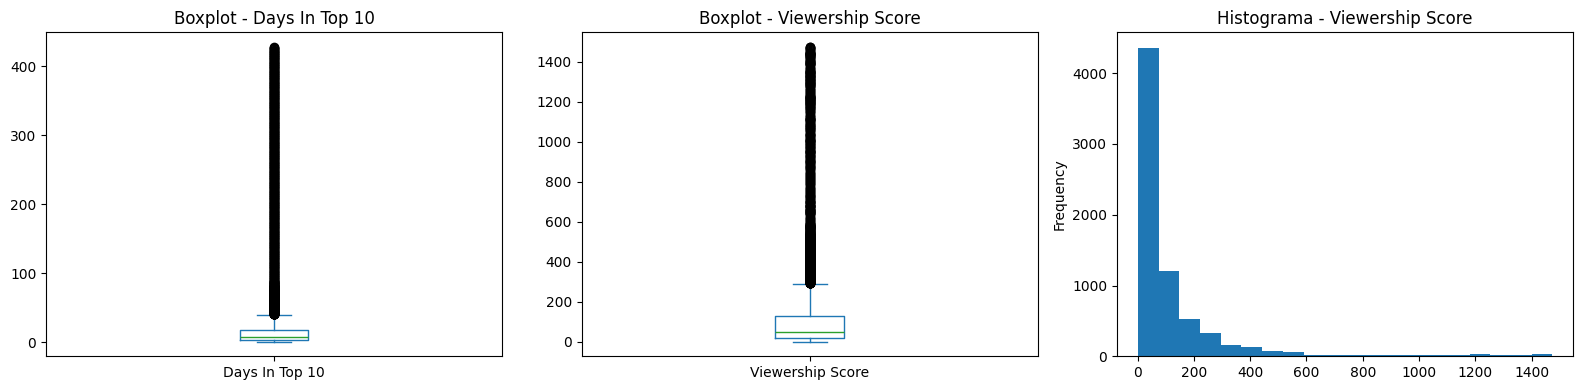

In [12]:
# Gráficos da análise
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['Days In Top 10'].plot.box(ax=axes[0], title='Boxplot - Days In Top 10')
df['Viewership Score'].plot.box(ax=axes[1], title='Boxplot - Viewership Score')
df['Viewership Score'].plot.hist(ax=axes[2], bins=20, title='Histograma - Viewership Score')
for ax in axes:
    ax.set_xlabel('')
plt.tight_layout()
plt.show()
